# **How neural network learns linear function**
The process is basically the same for every amount of dimension. The only difference is the amount of needed calculations.

Generalised form of linear function in n-dimension is
$$
y = W^T X + b
$$
where:
- $\displaystyle X = \begin{bmatrix} x_1 \\ x_2 \\ \vdots \\ x_n \end{bmatrix}$ - input vector

- $\displaystyle W = \begin{bmatrix} w_1 \\ w_2 \\ \vdots \\ w_n \end{bmatrix}$ - weight vector

- b - bias


In [1]:
import torch
from torch import nn

import matplotlib.pyplot as plt

## 2-dimensional case

Here, we will be using well known linear function formula
$$y = ax + b$$
where:
- a - weight
- b - bias

### 0. Defining the parameters of target function - weight and bias

In [2]:
weight = 1.5
bias = 2

## 1. Creating, spliting and analysing data

### 1.1 Let's start with creating a 100 sample dataset

In [3]:
X = torch.arange(start=0, end=2, step=0.02).unsqueeze(dim=1)
y = weight * X + bias

In [4]:
X.shape, y.shape

(torch.Size([100, 1]), torch.Size([100, 1]))

### 1.2 In this step, we are going to split the data into:
- training dataset - used for training
- testing dataset - used for checking the performance of our model
- visualize those datasets

The typical division is 80% for training, 20% for testing and that is what we're going to do in this case

**Note**: This time, we're going to make this by hand, but later we will be using the method build in *sklearn.model_selection train_test_split*

https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html

In [5]:
split_idx = int(len(X) * 0.8)

X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

In [6]:
len(X_train), len(X_test), len(y_train), len(y_test)

(80, 20, 80, 20)

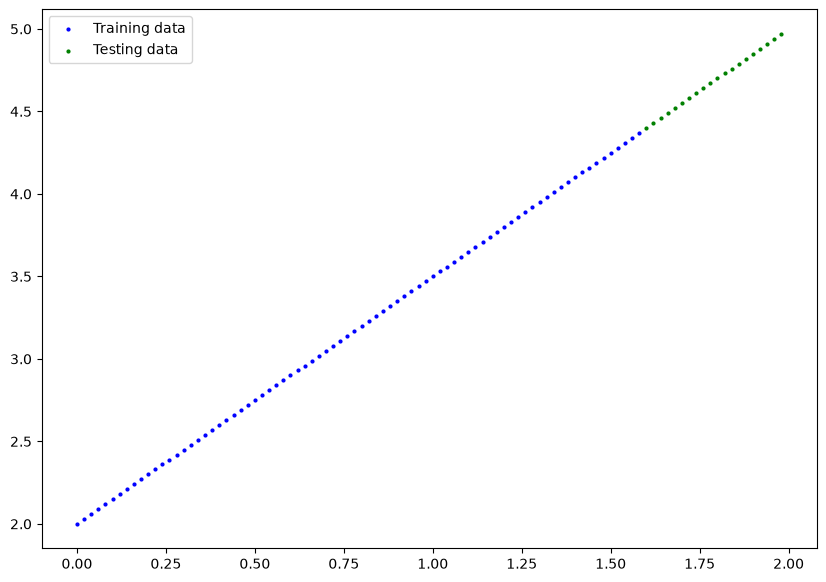

In [7]:
from visualization import plot_predictions

plot_predictions(train_data=X_train, train_labels=y_train, test_data=X_test, test_labels=y_test, predictions=None)

## 2. Model

## 2.1 Building a model

Our model starts with random parameters, in this case weight and bias

At the end of this step, we will also check the random parameters before training, and try to make a predictions with this untrained model

**Note: It is very important to set the manual seed to get reproducible results in case we wanted to improve our model or experiment with it**

In [8]:
class LinearFunction2D(nn.Module):
    def __init__(self):
        super().__init__()
        self.weight= nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))
        self.bias = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))

    # We must override the 'forward' method to define the computation in the model. Not doing so, would result in an error
    # Making predictions using forward methods is also called 'forward propagation'
    def forward(self, X: torch.Tensor) -> torch.Tensor:
        return self.weight * X + self.bias


In [9]:
torch.manual_seed(1)

In [10]:
# Instantiasing model and checking the random values of parameters
linear2d_model = LinearFunction2D()
linear2d_model.state_dict()

OrderedDict([('weight', tensor([0.6614])), ('bias', tensor([0.2669]))])

In [11]:
with torch.inference_mode():
    predicted_labels = linear2d_model(X_test)

# plot_data(training_data=X_train, training_labels=y_train, testing_data=X_test, testing_labels=y_test, predictions=predicted_labels)

## 2.2 Training the model

Training the model is basically adjusting the initial random values to get a better representation of data through iterating through the training data

Important components of training:
- **Gradient descent** - optimization algorithm used to find the minimum of the function
- **Backpropagation** - it calculates the gradient of loss function, by applying the chain rule backward from the output layer to the input layer. This allows an optimizer (like gradient descent) to update weights and reduce errors
- **Loss function** - indicates how poorly our model works
- **Optimizer** - looks at the loss function and adjusts the model parameters to improve it
- **epochs** - amount of times, we go through the training data
- **learning rate** (lr) - the "size" of optimizer step, it's very important to find the sweetspot there, because when lr is too low, the training will be too slow, and when lr is too high training is unstable

We will also need to build a training and testing loops

Training loop (and testing loop)

`iterate through the data` -> `making predictions using forward() method` -> `calculating the loss` -> `clearing old gradients` -> `backpropagation` -> `optimizer step`

In this case we will be using:
- MSELoss() as a loss function (Mean Squared Error)
- SGD as optimizer (Stochastic Gradient Descent)



In [12]:
ls_func = nn.MSELoss()
optim = torch.optim.SGD(params=linear2d_model.parameters(), lr=0.01)

In [13]:
epochs = 200

epoch_counts = []
loss_vals = []
test_loss_vals = []

# Training
for epoch in range(epochs):
    linear2d_model.train()
    y_predicted = linear2d_model(X_train)
    loss = ls_func(y_predicted, y_train)
    optim.zero_grad()
    loss.backward()
    optim.step()

    # Testing
    linear2d_model.eval()
    with torch.inference_mode():
        y_test_predicted = linear2d_model(X_test)
        test_loss = ls_func(y_test_predicted, y_test)

    if epoch % 10 == 0:
        epoch_counts.append(epoch)
        loss_vals.append(loss.item())
        test_loss_vals.append(test_loss.item())
        print(f"Epoch: {epoch}, Loss: {loss}, Test loss: {test_loss}")
        print(linear2d_model.state_dict())


Epoch: 0, Loss: 5.888956546783447, Test loss: 9.694159507751465
OrderedDict([('weight', tensor([0.7028])), ('bias', tensor([0.3148]))])
Epoch: 10, Loss: 2.9490532875061035, Test loss: 4.416065216064453
OrderedDict([('weight', tensor([1.0449])), ('bias', tensor([0.7138]))])
Epoch: 20, Loss: 1.4841917753219604, Test loss: 1.9310693740844727
OrderedDict([('weight', tensor([1.2838])), ('bias', tensor([0.9977]))])
Epoch: 30, Loss: 0.7539366483688354, Test loss: 0.7915693521499634
OrderedDict([('weight', tensor([1.4497])), ('bias', tensor([1.2004]))])
Epoch: 40, Loss: 0.3895506262779236, Test loss: 0.29086756706237793
OrderedDict([('weight', tensor([1.5643])), ('bias', tensor([1.3457]))])
Epoch: 50, Loss: 0.20740143954753876, Test loss: 0.08680623024702072
OrderedDict([('weight', tensor([1.6427])), ('bias', tensor([1.4504]))])
Epoch: 60, Loss: 0.1160394698381424, Test loss: 0.015719544142484665
OrderedDict([('weight', tensor([1.6956])), ('bias', tensor([1.5265]))])
Epoch: 70, Loss: 0.0699209

## 3. Analysing model output

### 3.1 Plotting model predictions

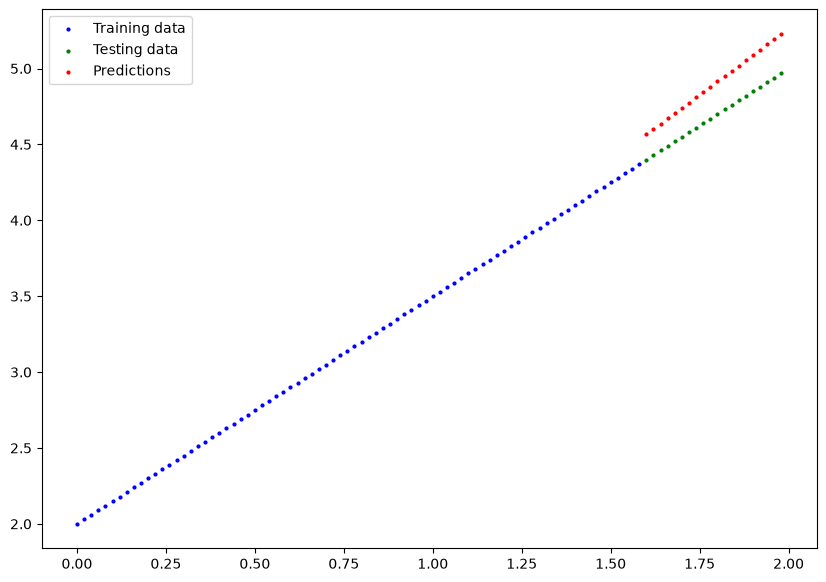

In [14]:
linear2d_model.eval()
with torch.inference_mode():
    test_predictions = linear2d_model(X_test)

plot_predictions(train_data=X_train, train_labels=y_train, test_data=X_test, test_labels=y_test, predictions=test_predictions)


### 3.2 Plotting training loss and testing loss

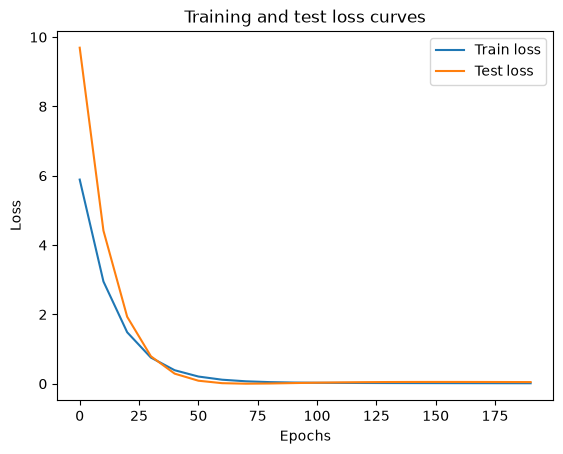

In [15]:
import numpy as np

plt.plot(epoch_counts, np.array(torch.tensor(loss_vals).numpy()), label = "Train loss")
plt.plot(epoch_counts, test_loss_vals, label = "Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();

## 4. Saving model to a file

We simply save model state dict to a file

It is recomended to save PyTorch models in files with .pt or .pth extensions

In [16]:
from pathlib import Path

models_cat = Path("models")
models_cat.mkdir(parents=True, exist_ok=True)

model_name = "linear2D_model.pth"
model_path = models_cat / model_name
torch.save(obj=linear2d_model.state_dict(), f=model_path)
